1. How many tennis players are included in the dataset?

In [3]:
import pandas as pd
import glob
import os

base_path = '../data/input/tennis_data/'
all_files = glob.glob(os.path.join(base_path, '**/*.parquet'), recursive=True)

dfs = []

for i, file in enumerate(all_files[:10000]):  # برای شروع ۱۰ هزار فایل اول رو بخون
    try:
        df = pd.read_parquet(file, columns=['player_id'])
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

combined_df = pd.concat(dfs, ignore_index=True)
combined_df.to_parquet('players_combined.parquet')


Error reading ../data/input/tennis_data\20240201\data\raw\raw_match_parquet\away_team_score_11974053.parquet: No match for FieldRef.Name(player_id) in match_id: int64
current_score: int64
display_score: int64
period_1: null
period_2: null
period_3: null
period_4: null
period_5: null
period_1_tie_break: null
period_2_tie_break: null
period_3_tie_break: null
period_4_tie_break: null
period_5_tie_break: null
normal_time: null
__fragment_index: int32
__batch_index: int32
__last_in_fragment: bool
__filename: string
Error reading ../data/input/tennis_data\20240201\data\raw\raw_match_parquet\away_team_score_11974066.parquet: No match for FieldRef.Name(player_id) in match_id: int64
current_score: int64
display_score: int64
period_1: null
period_2: null
period_3: null
period_4: null
period_5: null
period_1_tie_break: null
period_2_tie_break: null
period_3_tie_break: null
period_4_tie_break: null
period_5_tie_break: null
normal_time: null
__fragment_index: int32
__batch_index: int32
__last_in_fr

In [1]:
import pandas as pd

df = pd.read_parquet('players_combined.parquet')
num_players = df['player_id'].dropna().nunique()
print("Unique players:", num_players)


Unique players: 673


3.Which player has the highest number of wins? 

In [8]:
import glob
import os
import pandas as pd

base_path = '../data/input/tennis_data/'

# گرفتن همه فایل‌های پارکت توی پوشه‌های مختلف
all_files = glob.glob(os.path.join(base_path, '**/*.parquet'), recursive=True)

# بررسی 10 فایل اول برای پیدا کردن فایل حاوی نتایج مسابقات
for file in all_files[:10]:
    try:
        df = pd.read_parquet(file)
        print(f"File: {file}")
        print(df.columns)
        print(df.head(1))
        print('-'*40)
    except Exception as e:
        print(f"Error reading {file}: {e}")


File: ../data/input/tennis_data\20240201\data\raw\raw_match_parquet\away_team_11998445.parquet
Index(['match_id', 'name', 'slug', 'gender', 'user_count', 'residence',
       'birthplace', 'height', 'weight', 'plays', 'turned_pro',
       'current_prize', 'total_prize', 'player_id', 'current_rank',
       'name_code', 'country', 'full_name'],
      dtype='object')
   match_id                name                   slug gender  user_count  \
0  11998445  Auger-Aliassime F.  auger-aliassime-felix      M       23318   

             residence        birthplace  height  weight         plays  \
0  Monte Carlo, Monaco  Montreal, Canada    1.93      87  right-handed   

  turned_pro  current_prize  total_prize  player_id  current_rank name_code  \
0       2017         218538     10166964     192013            30       AUG   

  country               full_name  
0  Canada  Auger-Aliassime, Felix  
----------------------------------------
File: ../data/input/tennis_data\20240201\data\raw\raw_matc

In [1]:
import pyarrow
print(pyarrow.__version__)


20.0.0


In [2]:
pip install tqdm

     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     ------- -------------------------------- 10.2/57.7 kB ? eta -:--:--
     ------------- ------------------------ 20.5/57.7 kB 217.9 kB/s eta 0:00:01
     -------------------- ----------------- 30.7/57.7 kB 187.9 kB/s eta 0:00:01
     -------------------- ----------------- 30.7/57.7 kB 187.9 kB/s eta 0:00:01
     --------------------------------- ---- 51.2/57.7 kB 201.8 kB/s eta 0:00:01
     -------------------------------------- 57.7/57.7 kB 189.7 kB/s eta 0:00:00
   ---------------------------------------- 0.0/78.5 kB ? eta -:--:--
   -------------------- ------------------- 41.0/78.5 kB 991.0 kB/s eta 0:00:01
   ------------------------------------ --- 71.7/78.5 kB 991.0 kB/s eta 0:00:01
   ---------------------------------------- 78.5/78.5 kB 734.4 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pyarrow.parquet as pq
import glob
from tqdm import tqdm
import pandas as pd

# همه فایل‌های مورد نظر (home و away)
away_files = glob.glob('../data/input/tennis_data/**/*away_team_*.parquet', recursive=True)
home_files = glob.glob('../data/input/tennis_data/**/*home_team_*.parquet', recursive=True)
file_paths = away_files + home_files

# لیست برای ذخیره نتایج
records = []

# با tqdm برای نوار پیشرفت
for path in tqdm(file_paths, desc="در حال خواندن فایل‌ها"):
    try:
        table = pq.read_table(path, columns=['player_id', 'full_name', 'total_prize'])
        df = table.to_pandas()
        if not df.empty and pd.notnull(df.iloc[0]['player_id']) and pd.notnull(df.iloc[0]['total_prize']):
            records.append({
                'player_id': df.iloc[0]['player_id'],
                'full_name': df.iloc[0]['full_name'],
                'total_prize': df.iloc[0]['total_prize']
            })
    except Exception as e:
        continue  # خطاهای احتمالی رو رد می‌کنیم

# تبدیل به DataFrame
result_df = pd.DataFrame(records)

# حذف رکوردهای خالی یا تکراری و پیدا کردن بیشترین total_prize
result_df.dropna(subset=['player_id', 'total_prize'], inplace=True)
result_df = result_df.sort_values('total_prize', ascending=False).drop_duplicates('player_id')

top_player = result_df.iloc[0]
print(f"\n🏆 بازیکنی با بیشترین total prize:\n{top_player['full_name']} — ${top_player['total_prize']:,}")


در حال خواندن فایل‌ها: 100%|██████████| 120030/120030 [08:48<00:00, 226.96it/s]



🏆 بازیکنی با بیشترین total prize:
Djokovic, Novak — $151,703,255


5. How many sets are typically played in a tennis match? 

In [16]:
pip install prettytable


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
n = min(5, len(df))
sampled_df = df.sample(n)
display(sampled_df)


,match_id,name,slug,gender,user_count,residence,birthplace,height,weight,plays,turned_pro,current_prize,total_prize,player_id,current_rank,name_code,country,full_name
0,11998445,Auger-Aliassime F.,auger-aliassime-felix,M,23318,"Monte Carlo, Monaco","Montreal, Canada",1.93,87,right-handed,2017,218538,10166964,192013,30,AUG,Canada,"Auger-Aliassime, Felix"


In [27]:
all_columns = set()

for file in files:
    df = pd.read_parquet(file)
    all_columns.update(df.columns)

print(all_columns)


{'name_code', 'period_3', 'current_period_start_timestamp', 'start_datetime', 'tournament_id', 'display_inverse_home_away_teams', 'custom_id', 'home_team_seed', 'match_id', 'total_prize', 'year', 'normal_time', 'weight', 'round_id', 'crowd_sourcing_enabled', 'city', 'turned_pro', 'first_to_serve', 'away_team_seed', 'final_result_only', 'tennis_points', 'period_3_tie_break', 'tournament_category_name', 'has_performance_graph_feature', 'season_id', 'period_5', 'stadium', 'venue_id', 'period_5_tie_break', 'period_1_tie_break', 'current_rank', 'match_slug', 'tournament_category_slug', 'competition_type', 'birthplace', 'period_2_tie_break', 'display_score', 'current_score', 'gender', 'ground_type', 'period_4_tie_break', 'tournament_name', 'slug', 'name', 'current_prize', 'user_count', 'period_1', 'has_event_player_statistics', 'tournament_unique_id', 'cup_round_type', 'country', 'priority', 'period_2', 'winner_code', 'player_id', 'default_period_count', 'residence', 'full_name', 'tournament

In [1]:
import pandas as pd
import os

folder_path = '../data/input/tennis_data/20240201/data/raw/raw_match_parquet'  # مسیر پوشه‌ت رو بزار اینجا
files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.parquet')]

target_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']
files_with_all_periods = []

for file in files:
    try:
        df = pd.read_parquet(file, engine='pyarrow')
        if all(col in df.columns for col in target_cols):
            files_with_all_periods.append(file)
    except Exception as e:
        print(f'خطا در فایل {file}: {e}')

print(f'تعداد فایل‌هایی که همه ستون‌های period رو دارن: {len(files_with_all_periods)}')


تعداد فایل‌هایی که همه ستون‌های period رو دارن: 855


In [3]:
import pandas as pd

period_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']
total_sets = []
total_matches = 0

for file in files_with_all_periods:
    df = pd.read_parquet(file, engine='pyarrow')
    
    # حذف ردیف‌هایی که همه periodهاش None هستن
    if df[period_cols].notna().sum(axis=1).sum() == 0:
        continue

    df['sets_played'] = df[period_cols].notna().sum(axis=1)
    total_sets.extend(df['sets_played'].tolist())
    total_matches += len(df)

# محاسبه‌ی میانگین ست‌ها
if total_sets:
    avg_sets = sum(total_sets) / len(total_sets)
    print(f'🎾 میانگین تعداد ست‌های بازی‌شده در مجموع {len(total_sets)} مسابقه: {avg_sets:.2f}')
else:
    print('هیچ مسابقه‌ای با اطلاعات ست معتبر پیدا نشد.')


🎾 میانگین تعداد ست‌های بازی‌شده در مجموع 818 مسابقه: 2.34


13. What is the distribution of left-handed versus right-handed players?  

In [42]:
pip install dask[complete] --quiet


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import pandas as pd
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

folder_path = r"C:\Users\ASUSE\Desktop\data-analysis-project\Data-Analysis-Mini-Project\data\input\tennis_data"

# گرفتن همه فایل‌های away_team
def list_away_team_files(path):
    return [
        os.path.join(root, file)
        for root, _, files in os.walk(path)
        for file in files
        if file.endswith(".parquet") and "away_team" in file
    ]

# پردازش هر فایل
def process_file(file_path):
    try:
        df = pd.read_parquet(file_path, columns=["plays"])
        return Counter(df["plays"].dropna())
    except:
        return Counter()

def main():
    files = list_away_team_files(folder_path)
    all_counts = Counter()

    with ThreadPoolExecutor(max_workers=16) as executor:
        futures = {executor.submit(process_file, f): f for f in files}
        for f in tqdm(as_completed(futures), total=len(futures), desc="در حال پردازش سریع"):
            all_counts += f.result()

    total = sum(all_counts.values())
    percentages = {k: round((v / total) * 100, 2) for k, v in all_counts.items()}

    print("\n✅ تعداد بازیکنان به تفکیک دست بازی:")
    for k, v in all_counts.items():
        print(f"{k}: {v}")

    print("\n✅ درصد بازیکنان به تفکیک دست بازی:")
    for k, v in percentages.items():
        print(f"{k}: {v}%")

main()


در حال پردازش سریع: 100%|██████████| 59256/59256 [01:59<00:00, 496.06it/s]



✅ تعداد بازیکنان به تفکیک دست بازی:
left-handed: 1465
right-handed: 10494

✅ درصد بازیکنان به تفکیک دست بازی:
left-handed: 12.25%
right-handed: 87.75%


In [16]:
import os
import pandas as pd
from tqdm import tqdm

# مسیر اصلی دیتاست
base_path = r"C:\Users\ASUSE\Desktop\data-analysis-project\Data-Analysis-Mini-Project\data\input\tennis_data"
output_path = r"C:\Users\ASUSE\Desktop\data-analysis-project\Data-Analysis-Mini-Project\data\output\all_players.parquet"

# جمع‌آوری مسیر تمام فایل‌های مورد نظر
parquet_files = []
for root, _, files in os.walk(base_path):
    for f in files:
        if f.startswith("away_team_") and f.endswith(".parquet"):
            parquet_files.append(os.path.join(root, f))

# خواندن فقط ستون plays از هر فایل
plays_list = []
for file in tqdm(parquet_files, desc="Reading parquet files"):
    try:
        df = pd.read_parquet(file, columns=["plays"])
        plays_list.append(df)
    except Exception:
        continue  # ارورهایی مثل نبود ستون plays یا خراب بودن فایل رو رد می‌کنیم

# ترکیب و ذخیره
if plays_list:
    df_all = pd.concat(plays_list, ignore_index=True)
    df_all.to_parquet(output_path)
    print(f"✅ فایل خروجی ساخته شد. تعداد ردیف‌ها: {len(df_all)}")
else:
    print("⚠️ هیچ فایل معتبری برای ستون plays پیدا نشد.")


Reading parquet files: 100%|██████████| 59256/59256 [04:22<00:00, 225.89it/s]


✅ فایل خروجی ساخته شد. تعداد ردیف‌ها: 24203


C:\Users\ASUSE\AppData\Local\Temp\ipykernel_25140\1605530802.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plays_count.index, y=plays_count.values, palette="viridis")


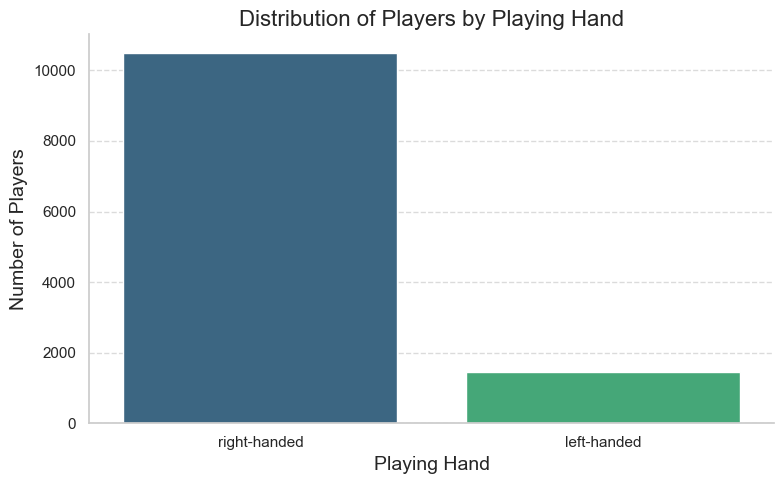

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# فرض کن داده‌ها توی df هست و ستون 'plays' شامل دست بازی بازیکنانه
plays_count = df['plays'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=plays_count.index, y=plays_count.values, palette="viridis")

plt.title("Distribution of Players by Playing Hand", fontsize=16)
plt.xlabel("Playing Hand", fontsize=14)
plt.ylabel("Number of Players", fontsize=14)

# خطوط افقی خط‌چین با شفافیت مناسب
plt.grid(axis='y', linestyle='--', alpha=0.7)

# حذف خطوط بالا و راست نمودار (حذف spines بالا و راست)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()
